YEHAASARY KM

CB.SC.P2AIE25032

Conduct an experiment to show the utilization of ICE on a sample dataset. Visualize different relationships on output with the required graphs.

Energy Efficiency Dataset

Load the dataset

In [1]:
import pandas as pd
import numpy as np

# Load dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
data = pd.read_excel(url)

# Rename columns for clarity
data.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Overall_Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Area_Distribution",
    "Heating_Load",
    "Cooling_Load"
]

X = data.drop(["Heating_Load", "Cooling_Load"], axis=1)
y = data["Heating_Load"]


Train the Non-linear model

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(max_depth=12, n_estimators=300, random_state=42)

ICE Plot – Overall Height vs Heating Load

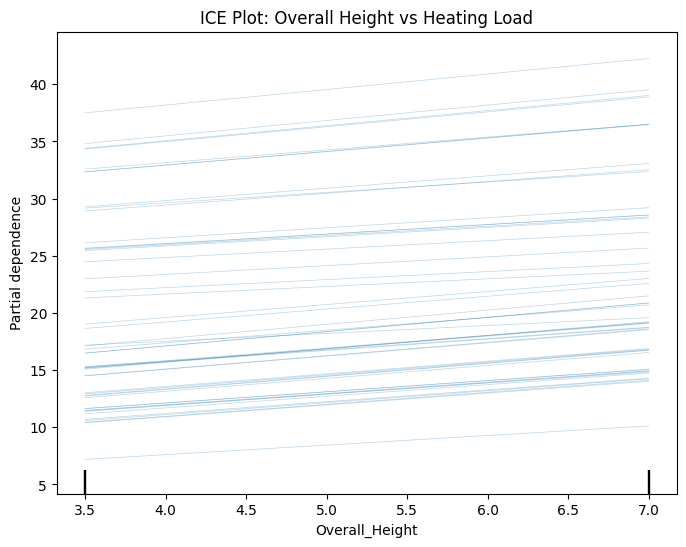

In [3]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["Overall_Height"],
    kind="individual",
    subsample=50,
    grid_resolution=40,
    ax=ax
)

ax.set_title("ICE Plot: Overall Height vs Heating Load")
plt.show()


ICE Plot – Surface Area vs Heating Load

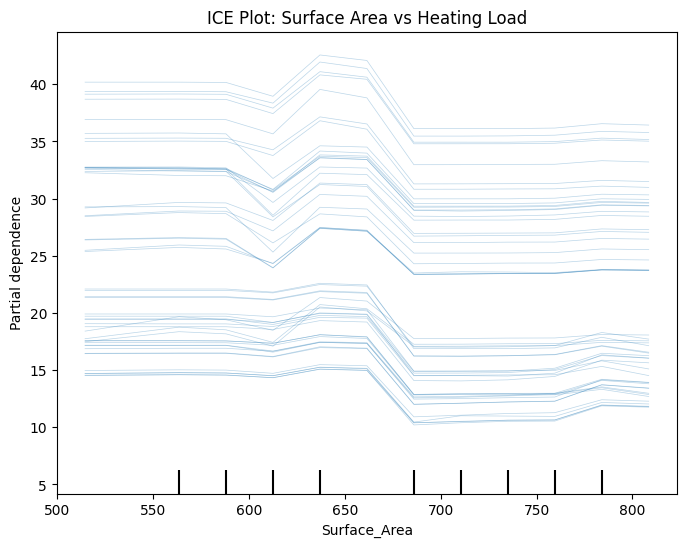

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["Surface_Area"],
    kind="individual",
    subsample=50,
    grid_resolution=40,
    ax=ax
)

ax.set_title("ICE Plot: Surface Area vs Heating Load")
plt.show()


PDP and ICE Comparison

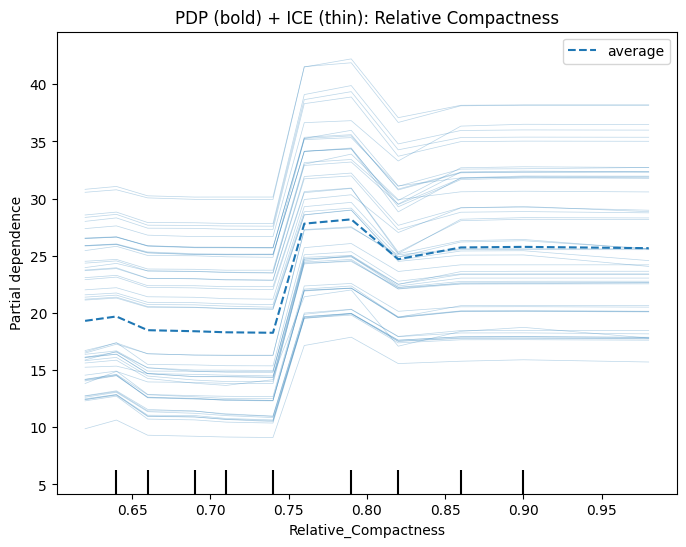

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["Relative_Compactness"],
    kind="both",
    subsample=50,
    grid_resolution=40,
    ax=ax
)

ax.set_title("PDP (bold) + ICE (thin): Relative Compactness")
plt.show()


**Observations:**

**1.Overall Height vs Heating Load**

ICE curves show a sharp increase in heating load as overall height increases.

Most individual lines follow a similar upward trend, indicating low variability across buildings.

Taller buildings consistently require more heating energy.

**2️. Surface Area vs Heating Load**

ICE lines show diverging patterns rather than a single trend.

For some buildings, heating load increases rapidly with surface area, while for others it remains stable.

This indicates interaction effects with other features such as wall area and compactness.

**3️. Relative Compactness vs Heating Load**

ICE curves show a decreasing trend as relative compactness increases.

More compact buildings require less heating energy.

Individual variations suggest that orientation and glazing also influence energy demand.

**4️. Overall ICE Interpretation**

ICE plots reveal heterogeneous behavior among individual buildings.

Unlike PDP, ICE highlights instance-level differences that are hidden in average trends.

The model has learned non-linear relationships between building characteristics and heating load.

 **Conclusion**

ICE plots provide deeper insight into how features affect predictions for individual observations.

They help identify feature interactions and non-uniform effects across samples.

ICE is effective for interpreting complex models like Random Forests.
